# Data Collection

## Objectives

- Retrieve the dataset from Kaggle and store it as raw data.
- Perform an initial inspection of the dataset.
- Save a cleaned copy of the dataset structure in `outputs/datasets/collection`.

## Inputs

- Kaggle API authentication file (`kaggle.json`)

## Outputs

- Raw dataset stored in: `inputs/datasets/rice_leaf_diseases`
- Dataset summary and inspection outputs saved in: `outputs/datasets/collection`

## Additional Comments

- The dataset is imbalanced, with some classes (e.g., Brown Spot, Leaf Smut) having significantly more samples than others.
- The dataset is provided in YOLO format, including images and corresponding annotation files.
- No major data cleaning is required at this stage, as the dataset is already pre-processed.

## Steps to Implement the Notebook

### 1. Install Required Python Packages

Install all project dependencies:

In [29]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


> **Note**: Ensure the requirements.txt file is up to date before running this step.

Add project imports

In [30]:
import os
from pathlib import Path
import subprocess
import zipfile
import glob
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

### 2. Set Working Directory

Adjust the working directory to the project root:

In [5]:
# Get project root
current_path = Path().resolve()

# Stop when we find project root
while not (current_path / "jupyter_notebooks").exists():
    if current_path == current_path.parent:
        raise Exception("Project root not found.")
    current_path = current_path.parent

PROJECT_ROOT = current_path

# Change working directory
os.chdir(PROJECT_ROOT)

print(f"New working directory: {Path().resolve()}")

New working directory: C:\code\ml\workspace\rice_leaf_diseases_analyser


> **Note**: This step ensures consistent relative paths across the notebook.

### 3. Install Kaggle API

Install the Kaggle package (specific version for compatibility):

In [8]:
# install kaggle package
%pip install kaggle==2.1.1

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


> **Note**: This package is required to download datasets directly from Kaggle using the API.

### 4. Configure Kaggle Credentials

Set the Kaggle configuration directory and permissions for the API token.

In [34]:
# Set Kaggle config directory to current working directory
os.environ['KAGGLE_CONFIG_DIR'] = str(Path().resolve())

# Checking if the operating system is not Windows (nt),
# then set permissions for kaggle.json
if os.name != "nt":
    subprocess.run(["chmod", "600", "kaggle.json"])

> **Note:** Make sure `kaggle.json` is present in the working directory.

### 5. Download and Extract Dataset

Download the dataset from Kaggle and store it in the raw data directory.

In [35]:
# Dataset info
KAGGLE_DATASET_PATH = "yusufmurtaza01/rice-leaf-diseases"

# Define destination folder using pathlib
DESTINATION_FOLDER = Path("inputs/datasets/raw")
DESTINATION_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Dataset will be stored in: {DESTINATION_FOLDER}")

# Download dataset
!kaggle datasets download -d {KAGGLE_DATASET_PATH} -p {DATASET_DIR}

print("Download completed.")

# Unzip dataset
zip_files = glob.glob(str(DESTINATION_FOLDER / "*.zip"))

for file in zip_files:
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall(DESTINATION_FOLDER)

print("Extraction completed.")

Dataset will be stored in: inputs\datasets\raw
Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/rice-leaf-diseases
License(s): CC0-1.0

Download completed.


Could not find platform independent libraries <prefix>

  0%|          | 0.00/463M [00:00<?, ?B/s]
  0%|          | 1.00M/463M [00:00<04:02, 2.00MB/s]
  1%|          | 3.00M/463M [00:00<01:27, 5.51MB/s]
  1%|▏         | 6.00M/463M [00:00<00:43, 11.0MB/s]
  2%|▏         | 10.0M/463M [00:00<00:27, 17.1MB/s]
  3%|▎         | 14.0M/463M [00:01<00:21, 21.5MB/s]
  4%|▍         | 18.0M/463M [00:01<00:18, 24.7MB/s]
  5%|▍         | 21.0M/463M [00:01<00:17, 25.8MB/s]
  5%|▌         | 24.0M/463M [00:01<00:17, 27.1MB/s]
  6%|▌         | 28.0M/463M [00:01<00:15, 28.7MB/s]
  7%|▋         | 32.0M/463M [00:01<00:15, 29.8MB/s]
  8%|▊         | 35.0M/463M [00:01<00:16, 27.3MB/s]
  8%|▊         | 38.0M/463M [00:02<00:20, 21.3MB/s]
  9%|▉         | 42.0M/463M [00:02<00:18, 23.5MB/s]
 10%|▉         | 45.0M/463M [00:02<00:17, 24.8MB/s]
 10%|█         | 48.0M/463M [00:02<00:18, 24.0MB/s]
 11%|█         | 51.0M/463M [00:02<00:17, 24.6MB/s]
 12%|█▏        | 55.0M/463M [00:02<00:15, 27.0MB/s]
 13%|█▎        | 

Extraction completed.


### 6. Verify Dataset Structure

In [11]:
DATASET_DIR = DESTINATION_FOLDER / "rice"

required_paths = [
    DATASET_DIR / "images/train",
    DATASET_DIR / "images/val",
    DATASET_DIR / "labels/train",
    DATASET_DIR / "labels/val",
]

for path in required_paths:
    print(f"{path}: {'Exists' if path.exists() else 'Missing'}")

inputs\datasets\raw\rice\images\train: Exists
inputs\datasets\raw\rice\images\val: Exists
inputs\datasets\raw\rice\labels\train: Exists
inputs\datasets\raw\rice\labels\val: Exists


### 7. Inspect Dataset Size

In [13]:
image_extensions = [".jpg", ".jpeg", ".png"]

train_images = [
    f for f in (DATASET_DIR / "images/train").glob("*")
    if f.suffix.lower() in image_extensions
]

val_images = [
    f for f in (DATASET_DIR / "images/val").glob("*")
    if f.suffix.lower() in image_extensions
]

print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")

Training images: 6935
Validation images: 1730


### 8. Class Distribution Analysis

In [22]:
class_counts = Counter()

label_files = list((DATASET_DIR / "labels/train").glob("*.txt"))

class_names = {
    0: "BacterialLeafBlight",
    1: "BrownSpot",
    2: "Healthy",
    3: "Hispa",
    4: "LeafBlast",
    5: "LeafScald",
    6: "LeafSmut",
    7: "NarrowBrownLeafSpot",
    8: "NeckBlast"
}

for label_file in label_files:
    with open(label_file, "r") as f:
        for line in f.readlines():
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

for item, count in class_counts.most_common():
    print(f"{class_names[item]}: {count}")

BrownSpot: 12368
LeafSmut: 5174
BacterialLeafBlight: 1876
NeckBlast: 771
Hispa: 734
Healthy: 661
LeafBlast: 596
NarrowBrownLeafSpot: 567
LeafScald: 446


### 9. Visualize Class Imbalance

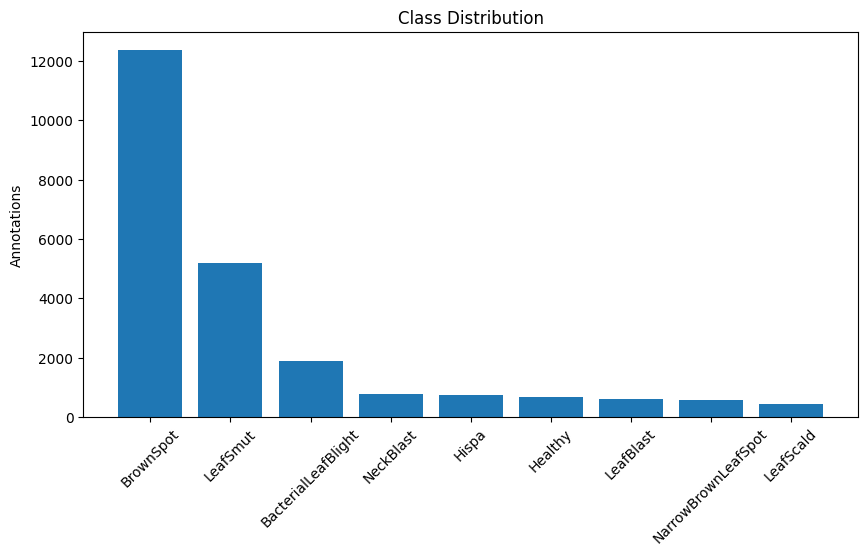

In [32]:
df_classes = pd.DataFrame({
    "Class": [class_names[k] for k in class_counts.keys()],
    "Count": class_counts.values()
})

df_classes = df_classes.sort_values("Count", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df_classes["Class"], df_classes["Count"])
plt.xticks(rotation=45)
plt.ylabel("Annotations")
plt.title("Class Distribution")
plt.show()

### 10. Save Collection Outputs

In [33]:
OUTPUT_DIR = Path("outputs/datasets/collection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df_classes.to_csv(
    OUTPUT_DIR / "class_distribution.csv",
    index=False
)

print("Collection outputs saved.")

Collection outputs saved.


## Conclusions

- The dataset was successfully downloaded and verified.
- The dataset contains noticeable class imbalance.
- The dataset structure is suitable for image classification workflows.
- Outputs generated in this notebook will support later exploratory analysis and model development.